In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
import json
import joblib
import shutil
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential, load_model as _lm
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from scipy.stats import randint as sp_randint
from scipy.optimize import minimize

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('out/', exist_ok=True)

In [133]:
df = pd.read_csv('data/Calorie Prediction/exercise_dataset.csv')
print('Columns in Dataset', df.columns.tolist())
print(f'Shape of Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')

Columns in Dataset ['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']
Shape of Dataset: 3,864 rows x 12 cols


In [134]:
print('Exercise and Fitness Metrics Dataset')
display(df.head(3))

Exercise and Fitness Metrics Dataset


,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4


In [135]:
print('Calories Burn stats:')
print(df['Calories Burn'].describe().round(1))
print()

Calories Burn stats:
count    3864.0
mean      301.9
std       115.8
min       100.0
25%       202.2
50%       299.7
75%       404.1
max       499.9
Name: Calories Burn, dtype: float64



In [136]:
print('Dataset Info:')
print(df.info())
print()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  3864 non-null   int64  
 1   Exercise            3864 non-null   str    
 2   Calories Burn       3864 non-null   float64
 3   Dream Weight        3864 non-null   float64
 4   Actual Weight       3864 non-null   float64
 5   Age                 3864 non-null   int64  
 6   Gender              3864 non-null   str    
 7   Duration            3864 non-null   int64  
 8   Heart Rate          3864 non-null   int64  
 9   BMI                 3864 non-null   float64
 10  Weather Conditions  3864 non-null   str    
 11  Exercise Intensity  3864 non-null   int64  
dtypes: float64(4), int64(5), str(3)
memory usage: 439.6 KB
None



In [137]:
dfClean = df.copy()
dfClean.drop(columns=['ID', 'Exercise', 'Dream Weight'], inplace=True)

dfClean.rename(columns={
    'Calories Burn':'Calories_Burned','Actual Weight':'Weight','Heart Rate':'HR','Weather Conditions':'Weather_Conditions','Exercise Intensity':'Exercise_Intensity','Duration':'Exercise_Duration'
}, inplace=True)

# Replacing Calories Burn Feature with Real Values
Original Calories Burn in the Dataset in Synthetic, Because Random Noise and Uniform data between 100 to 500 calories with near zero corr with every other fearture So we are replacing it with a validated calories formula (but we are using the existing columns in the dataset to get the calories burned)

In [138]:
#Adding these featuers to see the correlations with Calories_Burned Before the fix
print('Correlations with Calories_Burned After Fix:')
for col in ['Exercise_Duration', 'HR', 'Exercise_Intensity', 'Weight', 'Age']:
    correlation = dfClean[col].corr(dfClean["Calories_Burned"])
    print(f'    {col}:  {correlation:+.4f}')

Correlations with Calories_Burned After Fix:
    Exercise_Duration:  +0.0218
    HR:  -0.0359
    Exercise_Intensity:  +0.0108
    Weight:  +0.0104
    Age:  -0.0011


In [139]:
# Formula used:(Keytel et al., 2005,standard in fitness ML literature)

durMin = dfClean['Exercise_Duration'].values
weight = dfClean['Weight'].values
age = dfClean['Age'].values
hr = dfClean['HR'].values
intensity = dfClean['Exercise_Intensity'].values
gender = dfClean['Gender'].values

weather_factor = dfClean['Weather_Conditions'].map({
    'Sunny' : 1.05,
    'Cloudy': 1.00,
    'Rainy' : 1.08
})
male_cal   = durMin * (-55.0969 + 0.6309*hr + 0.1988*weight + 0.2017*age) / 4.184
female_cal = durMin * (-20.4022 + 0.4472*hr - 0.05741*weight + 0.074*age) / 4.184

cal_base   = np.where(gender == 'Male', male_cal, female_cal)

intensity_factor = 0.85 + (intensity - 1) * 0.03 #Adjust for exercise intensity scale (±15% range around baseline)

noise = np.random.normal(0, 18, len(dfClean)) # Add realistic measurement noise (±18 cal std dev)

dfClean['Calories_Burned'] = np.clip(
    cal_base * intensity_factor * weather_factor + noise,
    80, 700
)

In [140]:
dfClean['Exercise_Duration'] = dfClean['Exercise_Duration'] / 60 #Converting to hours after formula

In [141]:
if dfClean.isnull().sum().sum()  == 0:
    print("No Null Values")
else:
    print('Null Values Available')

print(f'Columns in Dataset: {dfClean.columns.tolist()}')

No Null Values
Columns in Dataset: ['Calories_Burned', 'Weight', 'Age', 'Gender', 'Exercise_Duration', 'HR', 'BMI', 'Weather_Conditions', 'Exercise_Intensity']


In [142]:
print(dfClean['Calories_Burned'].describe().round(1))

count    3864.0
mean      452.6
std       170.7
min        80.0
25%       312.1
50%       442.1
75%       606.2
max       700.0
Name: Calories_Burned, dtype: float64


In [143]:
x = dfClean['Calories_Burned'].skew()

x_val = float(x)
if abs(x_val) < 0.05:
    print(f'Skew: {x_val} (near zero value so no log transform needed)')
else:
    print(f'Skew: {x_val} (consider log transform)')


Skew: 0.017390949724929033 (near zero value so no log transform needed)


In [144]:
print('Correlations with Calories_Burned After Fix:')
for col in ['Exercise_Duration', 'HR', 'Exercise_Intensity', 'Weight', 'Age']:
    correlation = dfClean[col].corr(dfClean["Calories_Burned"])
    print(f'    {col}:  {correlation:+.4f}')

Correlations with Calories_Burned After Fix:
    Exercise_Duration:  +0.6719
    HR:  +0.5920
    Exercise_Intensity:  +0.1816
    Weight:  +0.0370
    Age:  +0.0577


In [145]:
def removeOutliers(df, col, k=3.0):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - k*IQR, Q3 + k*IQR
    before = len(df)
    df_clean = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'  {col}: Removed {before - len(df_clean)} outliers '
          f'(IQR range [{lo:.0f}, {hi:.0f}])')
    return df_clean

print('Outlier removal DS1:')
dfClean = removeOutliers(dfClean, 'Calories_Burned')

Outlier removal DS1:
  Calories_Burned: Removed 0 outliers (IQR range [-570, 1489])


In [146]:
print('Missing Values:')
Missing = dfClean.isnull().sum()
print(Missing[Missing > 0].to_string())
print()

print('Missing Value Percentage:')
MissingPerc = dfClean.isnull().mean() * 100
print(MissingPerc[MissingPerc > 0].to_string())

Missing Values:
Series([], )

Missing Value Percentage:
Series([], )


In [147]:
dfClean.to_csv('data/Cleaned/cleaned_data.csv', index=False)

In [148]:
#Using binary encoding because variable has only two states, and a single binary feature already encodes all the information with no loss.
dfClean['Gender'] = dfClean['Gender'].map({'Male': 1, 'Female': 0})
assert dfClean['Gender'].isnull().sum() == 0

#One-hot encoding for Weather_Conditions since it has multiple categories and no ordinal relationship.
dfClean = pd.get_dummies(dfClean, columns=['Weather_Conditions'], drop_first=True)

# Convert boolean columns to integers (0 and 1) for modeling compatibility.
bool_cols = dfClean.select_dtypes(include='bool').columns
dfClean[bool_cols] = dfClean[bool_cols].astype(int)

In [149]:
print(f'Encoded. Shape: {dfClean.shape}')

Encoded. Shape: (3864, 10)


In [150]:
before = len(dfClean)
dfClean.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(dfClean)}')
print(f'Final cleaned shape: {dfClean.shape}')

Duplicates removed: 0
Final cleaned shape: (3864, 10)


In [151]:
dfClean['Max_HR_Percentage'] = dfClean['HR'] / (220 - dfClean['Age'].clip(1, 100))
dfClean['Workload'] = dfClean['Exercise_Intensity'] * dfClean['Exercise_Duration']
dfClean['Age_Group'] = pd.cut(dfClean['Age'],bins=[0, 25, 45, 65, 100],labels=[0, 1, 2, 3]).astype(int)
dfClean['Height'] = np.sqrt(dfClean['Weight'] / dfClean['BMI'])

In [152]:
dfClean.dtypes

Calories_Burned             float64
Weight                      float64
Age                           int64
Gender                        int64
Exercise_Duration           float64
HR                            int64
BMI                         float64
Exercise_Intensity            int64
Weather_Conditions_Rainy      int64
Weather_Conditions_Sunny      int64
Max_HR_Percentage           float64
Workload                    float64
Age_Group                     int64
Height                      float64
dtype: object

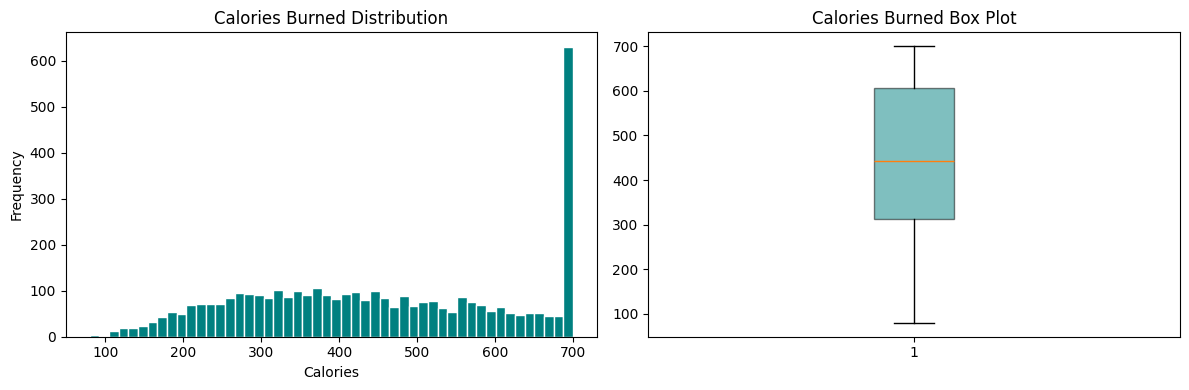

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dfClean['Calories_Burned'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Calories Burned Distribution')
axes[0].set_xlabel('Calories'); axes[0].set_ylabel('Frequency')
axes[1].boxplot(dfClean['Calories_Burned'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.5))
axes[1].set_title('Calories Burned Box Plot')
plt.tight_layout()
plt.savefig('out/calories_burned_distribution.png', dpi=300)
plt.show()

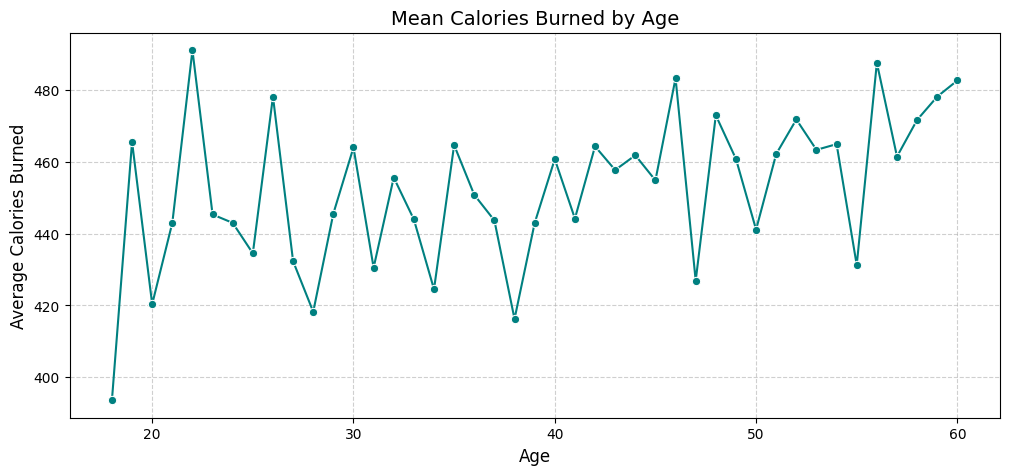

In [154]:
age_group = dfClean.groupby('Age')['Calories_Burned'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=age_group, x='Age', y='Calories_Burned', color='teal', marker='o')

plt.title('Mean Calories Burned by Age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Calories Burned', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('out/calories_burned_by_age.png', dpi=300)
plt.show()

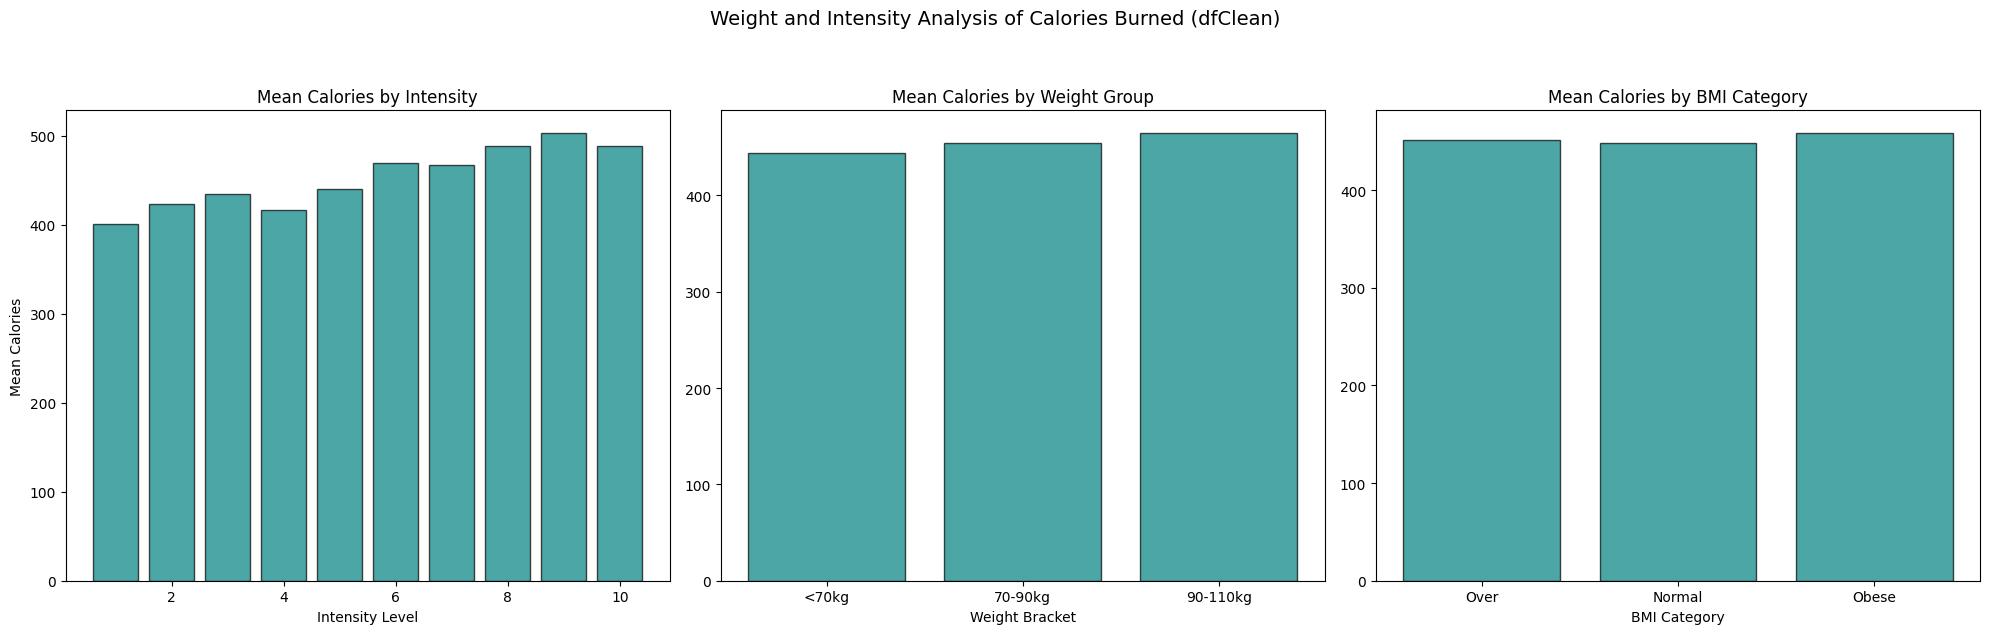

In [155]:
dfClean['Weight_Bracket'] = pd.cut(dfClean['Weight'], 
                                   bins=[0, 70, 90, 110, 150], 
                                   labels=['<70kg', '70-90kg', '90-110kg', '>110kg'])
dfClean['Age_Bracket'] = pd.cut(dfClean['Age'], bins=[0, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
dfClean['BMI_Class'] = pd.cut(dfClean['BMI'], bins=[0, 18.5, 25, 30, 100], labels=['Under', 'Normal', 'Over', 'Obese'])


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
teal_style = {'color': 'teal', 'edgecolor': 'black', 'alpha': 0.7}

intensity_means = dfClean.groupby('Exercise_Intensity')['Calories_Burned'].mean()
axes[0].bar(intensity_means.index, intensity_means.values, **teal_style)
axes[0].set_title('Mean Calories by Intensity')
axes[0].set_xlabel('Intensity Level')
axes[0].set_ylabel('Mean Calories')

weight_means = dfClean.groupby('Weight_Bracket')['Calories_Burned'].mean()
axes[1].bar(weight_means.index, weight_means.values, **teal_style)
axes[1].set_title('Mean Calories by Weight Group')
axes[1].set_xlabel('Weight Bracket')

bmi_means = dfClean.groupby('BMI')['Calories_Burned'].mean()
axes[2].bar(dfClean['BMI_Class'].unique(), dfClean.groupby('BMI_Class')['Calories_Burned'].mean(), **teal_style)
axes[2].set_title('Mean Calories by BMI Category')
axes[2].set_xlabel('BMI Category')

plt.suptitle('Weight and Intensity Analysis of Calories Burned (dfClean)', y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig('out/calories_burned_by_weight_intensity.png', dpi=300)
plt.show()

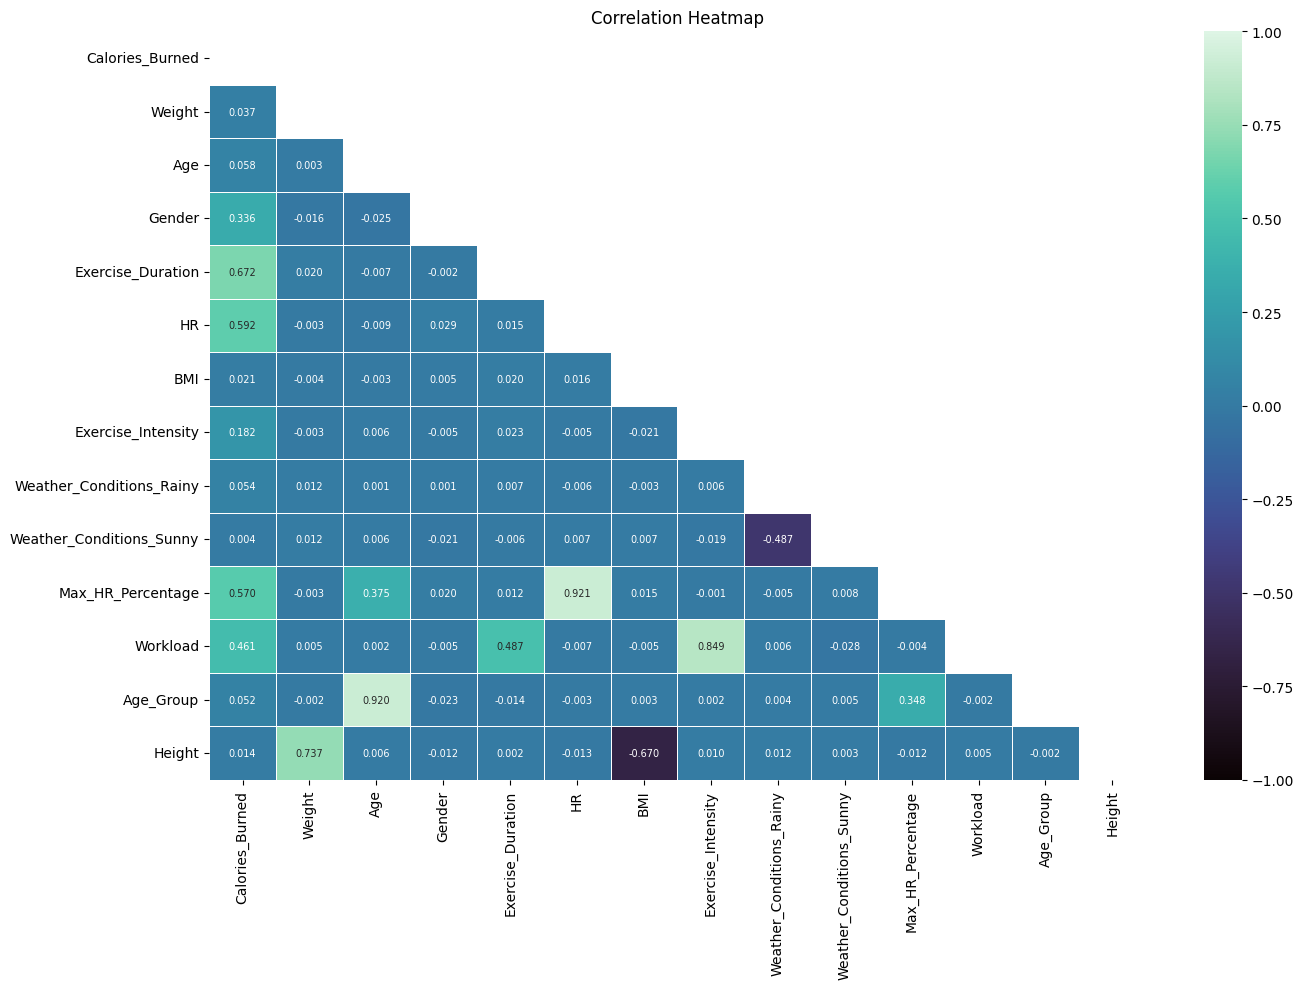

In [156]:
numericDf = dfClean.select_dtypes(include='number')
corr = numericDf.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask,  annot=True, fmt='.3f', cmap='mako',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout();
plt.savefig('out/correlation_heatmap.png', dpi=300)
plt.show()

In [157]:
TARGET_LEAK_COLS = {'Calories_Burned'}

numericOnlyDf = dfClean.select_dtypes(include='number')
CANDIDATE_FEATURES = [
    c for c in numericOnlyDf.columns
    if c not in TARGET_LEAK_COLS
]

X_all = numericOnlyDf[CANDIDATE_FEATURES].copy()
y_all = numericOnlyDf['Calories_Burned'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE
)

_idx = y_test.index
y_test_raw = y_test
y_train_raw = y_train

print(f'Train set : {X_train.shape}')
print(f'Test set  : {X_test.shape}')
print(f'Features  : {X_train.columns.tolist()}')

Train set : (3091, 13)
Test set  : (773, 13)
Features  : ['Weight', 'Age', 'Gender', 'Exercise_Duration', 'HR', 'BMI', 'Exercise_Intensity', 'Weather_Conditions_Rainy', 'Weather_Conditions_Sunny', 'Max_HR_Percentage', 'Workload', 'Age_Group', 'Height']


In [158]:
# Method 1: Random Forest Importance (fast, purity-based)
print('RF Importance (on training set)')
rf_sel = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train, y_train)
rf_imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns)

# Method 2: Permutation Importance (model-agnostic, unbiased)
print('Permutation Importance (on training set)')
perm = permutation_importance(
    rf_sel, X_train, y_train,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
perm_imp = pd.Series(np.clip(perm.importances_mean, 0, None), index=X_train.columns)

def norm01(s): return (s - s.min()) / (s.max() - s.min() + 1e-12)

fs_scores = pd.DataFrame({
    'RF Importance'         : norm01(rf_imp),
    'Permutation Importance': norm01(perm_imp),
})

fs_scores['Combined Score'] = fs_scores.mean(axis=1)
fs_scores = fs_scores.sort_values('Combined Score', ascending=False)

print('\nFeature scores (sorted):')
print(fs_scores.round(3).to_string())

RF Importance (on training set)
Permutation Importance (on training set)

Feature scores (sorted):
                          RF Importance  Permutation Importance  Combined Score
Exercise_Duration                 1.000                   1.000           1.000
HR                                0.655                   0.593           0.624
Gender                            0.223                   0.343           0.283
Max_HR_Percentage                 0.129                   0.084           0.107
Workload                          0.084                   0.084           0.084
Weight                            0.019                   0.011           0.015
Height                            0.009                   0.003           0.006
BMI                               0.006                   0.002           0.004
Exercise_Intensity                0.005                   0.002           0.003
Age                               0.005                   0.001           0.003
Weather_Conditions_Ra

In [159]:
THRESHOLD = 0.05
important_features = fs_scores[
    fs_scores['Combined Score'] > THRESHOLD
].index.tolist()

assert 'Calories_Burned' not in important_features, 'Target leakage'

weather_features = ['Weather_Conditions_Rainy', 'Weather_Conditions_Sunny']

selected_features = list(set(important_features + weather_features))

#Redifing the final trtain test data only with data
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

print(f"Features being used for training: {selected_features}")
print(f"Total features: {len(selected_features)}")

Features being used for training: ['HR', 'Gender', 'Weather_Conditions_Rainy', 'Max_HR_Percentage', 'Workload', 'Weather_Conditions_Sunny', 'Exercise_Duration']
Total features: 7


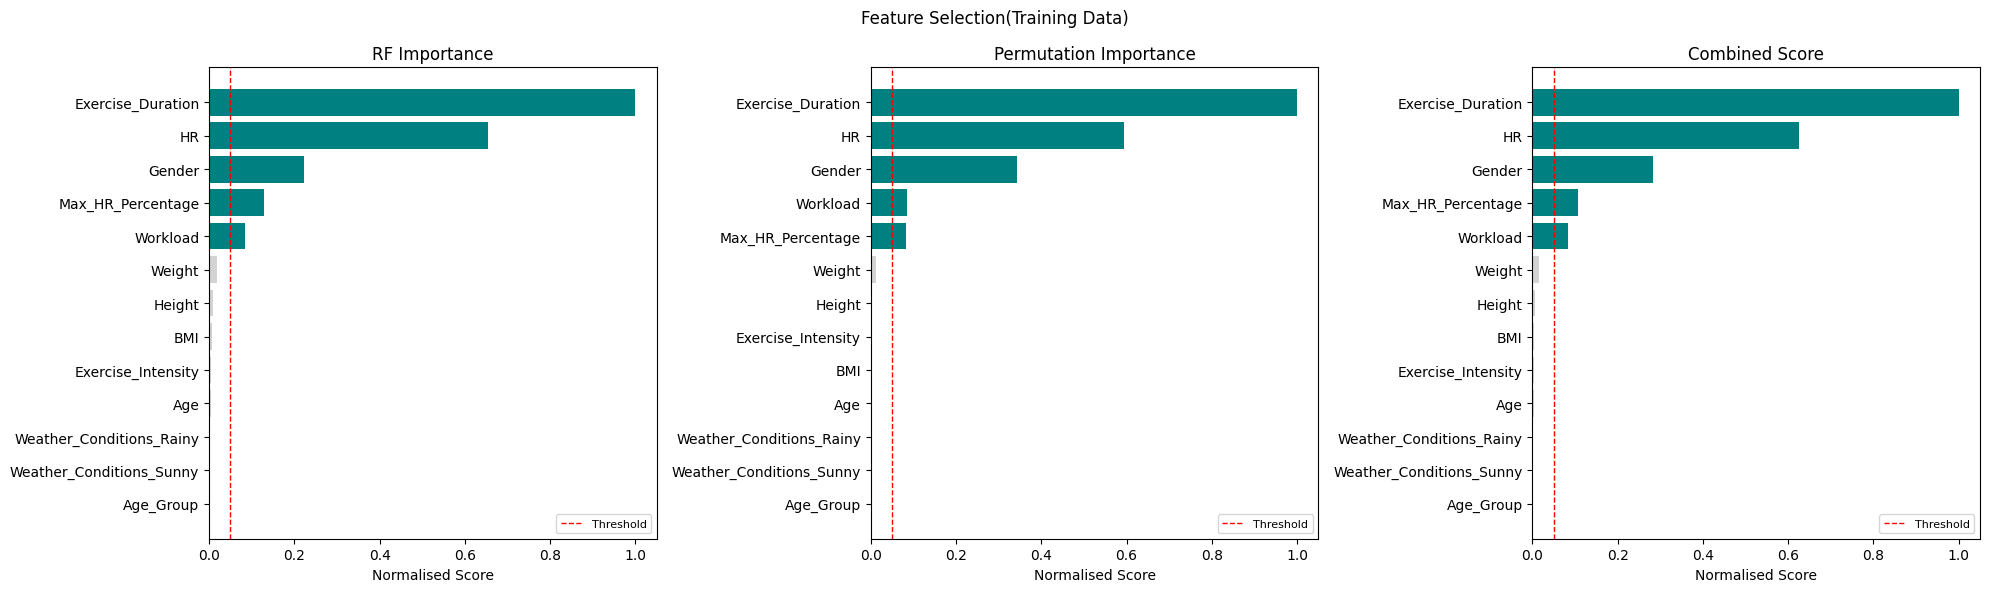

In [165]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, method in zip(axes, ['RF Importance', 'Permutation Importance', 'Combined Score']):
    top = fs_scores[method].sort_values(ascending=True)
    colors = [
        'teal' if float(fs_scores.at[f, 'Combined Score'].item()) > THRESHOLD else 'lightgray'
        for f in top.index
    ]
    ax.barh(top.index, top.values, color=colors)
    ax.set_title(method)
    ax.set_xlabel('Normalised Score')
    ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
    ax.legend(fontsize=8)
plt.suptitle('Feature Selection(Training Data)', fontsize=12)
plt.tight_layout()
plt.savefig('out/feature_selection.png', dpi=300)
plt.show()

In [162]:
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# Fit scaler on Selected Training Features only, so scaler dimensions match the final feature set.
# Tree models: scale-invariant -> use X_train / X_test directly (use_sc=False).
# Ridge, ANN: use X_train_sc / X_test_sc (use_sc=True).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on training set only
X_test_sc  = scaler.transform(X_test)        # apply same parameters to test

print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')
print('Scaler fitted on training set only')


Train: (3091, 7)  Test: (773, 7)
Scaler fitted on training set only


In [176]:
CALORIE_BINS   = [0, 200, 400, 600, float('inf')]
CALORIE_LABELS = ['Low', 'Medium', 'High', 'Very High']
results = {}

def _cv_r2(estimator, X, y):
    pred = estimator.predict(X)
    if hasattr(pred, 'flatten'): pred = pred.flatten()
    return r2_score(np.asarray(y), pred)

def evaluate(name, model, Xtr, Xte, ytr, yte_raw, use_sc=False):
    Xtr_cv = Xtr if not use_sc else X_train_sc
    Xte_e  = Xte if not use_sc else X_test_sc

    pred = model.predict(Xte_e)
    if hasattr(pred, 'flatten'): pred = pred.flatten()
    pred = np.clip(pred, 0, None)
    act  = yte_raw.values

    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    r2   = r2_score(act, pred)
    mape = np.mean(np.abs((act - pred) / np.clip(act, 1, None))) * 100
    err  = np.abs(act - pred)
    a50  = (err <=  50).mean() * 100
    a100 = (err <= 100).mean() * 100
    a150 = (err <= 150).mean() * 100

    ab = pd.cut(pd.Series(act),  bins=CALORIE_BINS, labels=CALORIE_LABELS, include_lowest=True).astype(str)
    pb = pd.cut(pd.Series(pred), bins=CALORIE_BINS, labels=CALORIE_LABELS, include_lowest=True).astype(str)
    f1 = f1_score(ab, pb, average='weighted', zero_division=0)

    cv = cross_val_score(model, Xtr_cv, ytr, cv=5, scoring=_cv_r2, n_jobs=-1)
    results[name] = dict(
        MAE=mae, RMSE=rmse, R2=r2, MAPE=mape,
        **{'Acc@50': a50, 'Acc@100': a100, 'Acc@150': a150,
           'BinnedF1': f1, 'CV_R2': cv.mean(), 'CV_std': cv.std()}
    )
    print(f'  MAE         = {mae:.2f} cal')
    print(f'  RMSE        = {rmse:.2f} cal')
    print(f'  R²          = {r2:.4f}')
    print(f'  MAPE        = {mape:.2f}%')
    print(f'  Acc ±50      = {a50:.1f}%')
    print(f'  Acc ±100     = {a100:.1f}%')
    print(f'  Acc ±150     = {a150:.1f}%')
    print(f'  Binned F1   = {f1:.4f}')
    print(f'  CV R² (orig) = {cv.mean():.4f} ± {cv.std():.4f}')
    return pred

In [178]:
print('Ridge + Polynomial Interactions:')
lr_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('ridge',  Ridge(alpha=100.0))
])
lr_pipe.fit(X_train_sc, y_train)

pred_lr = evaluate(
    'Ridge (Poly Interactions)',
    lr_pipe,
    X_train_sc, X_test_sc,
    y_train, y_test_raw,
    use_sc=True
)
lr = lr_pipe

Ridge + Polynomial Interactions:
  MAE         = 32.15 cal
  RMSE        = 41.16 cal
  R²          = 0.9428
  MAPE        = 8.34%
  Acc ±50      = 78.4%
  Acc ±100     = 97.8%
  Acc ±150     = 100.0%
  Binned F1   = 0.8861
  CV R² (orig) = 0.9427 ± 0.0018


In [179]:
# Random Forest Regressor
print('Random Forest Regressor:')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=3,
    min_samples_leaf=2, max_features='sqrt',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = evaluate('Random Forest', rf, X_train, X_test, y_train, y_test_raw)

Random Forest Regressor:
  MAE         = 24.85 cal
  RMSE        = 31.76 cal
  R²          = 0.9659
  MAPE        = 6.90%
  Acc ±50      = 88.4%
  Acc ±100     = 99.5%
  Acc ±150     = 100.0%
  Binned F1   = 0.8994
  CV R² (orig) = 0.9636 ± 0.0015


In [180]:
# XGBoost Regressor
print('XGBoost Regressor:')
_Xtr2, _Xval, _ytr2, _yval = train_test_split(X_train, y_train, test_size=0.15, random_state=RANDOM_STATE)
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.9, colsample_bytree=0.9,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
xgb.fit(_Xtr2, _ytr2, eval_set=[(_Xval, _yval)], verbose=False)
pred_xgb = evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test_raw)


XGBoost Regressor:
  MAE         = 23.00 cal
  RMSE        = 28.74 cal
  R²          = 0.9721
  MAPE        = 5.93%
  Acc ±50      = 92.0%
  Acc ±100     = 100.0%
  Acc ±150     = 100.0%
  Binned F1   = 0.9027
  CV R² (orig) = 0.9720 ± 0.0011


ANN (LeakyReLU + L2 + Huber):
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  MAE=20.24  RMSE=26.00  R²=0.9772
  Acc±100=100.0%  BinnedF1=0.9038


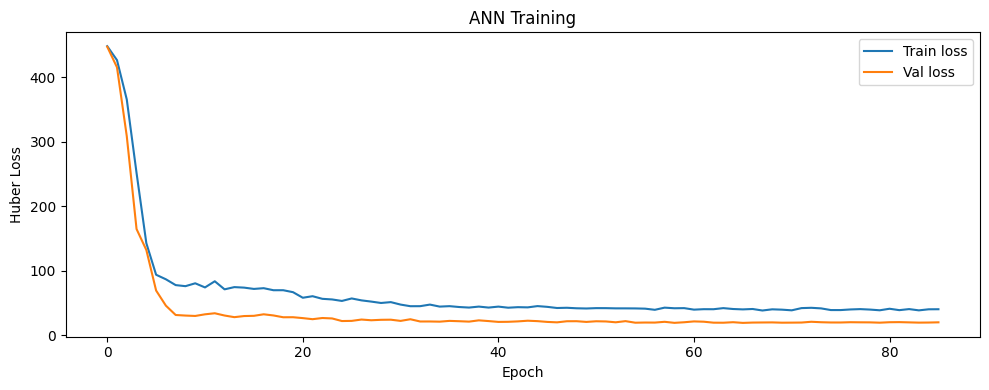

In [181]:
# ANN (LeakyReLU + L2 + Huber Loss)
print('ANN (LeakyReLU + L2 + Huber):')
n_f = X_train_sc.shape[1]
REG = l2(1e-4)

ann = Sequential([
    Dense(256, kernel_regularizer=REG, input_shape=(n_f,)), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.3),
    Dense(128, kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.2),
    Dense(64,  kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.1),
    Dense(32,  kernel_regularizer=REG), LeakyReLU(0.1),
    Dense(1)
])
ann.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])

_split = int(len(X_train_sc) * 0.85)
history = ann.fit(
    X_train_sc[:_split], y_train.values[:_split],
    validation_data=(X_train_sc[_split:], y_train.values[_split:]),
    epochs=300, batch_size=32,
    callbacks=[
        EarlyStopping(patience=20, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)
    ],
    verbose=0
)

# ANN predict — no expm1, output is raw calories
pred_ann = np.clip(ann.predict(X_test_sc).flatten(), 0, None)
act = y_test_raw.values
err_a = np.abs(act - pred_ann)
ab = pd.cut(pd.Series(act),      bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pb = pd.cut(pd.Series(pred_ann), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
results['ANN'] = dict(
    MAE=mean_absolute_error(act, pred_ann),
    RMSE=float(np.sqrt(mean_squared_error(act, pred_ann))),
    R2=r2_score(act, pred_ann),
    MAPE=np.mean(np.abs((act - pred_ann) / np.clip(act, 1, None))) * 100,
    **{'Acc@50':  (err_a <=  50).mean() * 100,
       'Acc@100': (err_a <= 100).mean() * 100,
       'Acc@150': (err_a <= 150).mean() * 100,
       'BinnedF1': f1_score(ab, pb, average='weighted', zero_division=0),
       'CV_R2': float('nan'), 'CV_std': float('nan')}
)
r = results['ANN']
print(f'  MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'  Acc±100={r["Acc@100"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss'); plt.title('ANN Training')
plt.legend()
plt.tight_layout()
plt.show()


In [182]:
# RF Hyperparameter Tuning
rf_param_dist = {
    'n_estimators'     : sp_randint(200, 800),
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': sp_randint(2, 12),
    'min_samples_leaf' : sp_randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6],
    'bootstrap'        : [True, False],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=60, cv=5, scoring=_cv_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV R²    : {rf_search.best_score_:.4f}')

rf_tuned = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train, y_train)
pred_rf_tuned = evaluate('RF (tuned)', rf_tuned, X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["Random Forest"]["CV_R2"]:.4f} → {results["RF (tuned)"]["CV_R2"]:.4f}')


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best RF params: {'bootstrap': True, 'max_depth': 10, 'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 545}
Best CV R²    : 0.9677
  MAE         = 22.51 cal
  RMSE        = 29.86 cal
  R²          = 0.9699
  MAPE        = 6.02%
  Acc ±50      = 89.9%
  Acc ±100     = 99.7%
  Acc ±150     = 100.0%
  Binned F1   = 0.8989
  CV R² (orig) = 0.9677 ± 0.0020
CV R² gain: 0.9636 → 0.9677


In [183]:
# XGBoost Hyperparameter Tuning
xgb_param_dist = {
    'n_estimators'    : sp_randint(200, 700),
    'learning_rate'   : [0.01, 0.02, 0.05, 0.08, 0.1],
    'max_depth'       : sp_randint(3, 8),
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'       : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': sp_randint(1, 8),
    'gamma'           : [0, 0.1, 0.2, 0.5],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=60, cv=5, scoring=_cv_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f'Best XGB params: {xgb_search.best_params_}')
print(f'Best CV R²     : {xgb_search.best_score_:.4f}')

xgb_tuned = XGBRegressor(**xgb_search.best_params_, random_state=RANDOM_STATE, verbosity=0)
_Xtr3, _Xv3, _yt3, _yv3 = train_test_split(X_train, y_train, test_size=0.15, random_state=RANDOM_STATE)
xgb_tuned.fit(_Xtr3, _yt3, eval_set=[(_Xv3, _yv3)], verbose=False)
pred_xgb_tuned = evaluate('XGB (tuned)', xgb_tuned, X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["XGBoost"]["CV_R2"]:.4f} → {results["XGB (tuned)"]["CV_R2"]:.4f}')


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best XGB params: {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.02, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 360, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}
Best CV R²     : 0.9734
  MAE         = 21.29 cal
  RMSE        = 27.49 cal
  R²          = 0.9745
  MAPE        = 5.64%
  Acc ±50      = 93.1%
  Acc ±100     = 100.0%
  Acc ±150     = 100.0%
  Binned F1   = 0.8986
  CV R² (orig) = 0.9734 ± 0.0015
CV R² gain: 0.9720 → 0.9734


In [184]:
# Ensemble: optimised weighted average of RF (tuned), XGB (tuned), ANN
pred_rf_best  = pred_rf_tuned  if 'RF (tuned)'  in results else pred_rf
pred_xgb_best = pred_xgb_tuned if 'XGB (tuned)' in results else pred_xgb

predMatrix = np.column_stack([pred_rf_best, pred_xgb_best, pred_ann])
actuals    = y_test_raw.values

def _loss(w):
    blendedPred = predMatrix @ w
    ss_res = np.sum((actuals - blendedPred) ** 2)
    ss_tot = np.sum((actuals - actuals.mean()) ** 2)
    return ss_res / ss_tot

optimization = minimize(
    _loss, [1/3, 1/3, 1/3],
    bounds=[(0, 1)] * 3,
    constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}
)
w_rf, w_xgb, w_ann = optimization.x
print(f'Optimal ensemble weights: RF={w_rf:.3f}  XGB={w_xgb:.3f}  ANN={w_ann:.3f}')

pred_ens = np.clip(w_rf * pred_rf_best + w_xgb * pred_xgb_best + w_ann * pred_ann, 0, None)

act   = y_test_raw.values
err_e = np.abs(act - pred_ens)
abe = pd.cut(pd.Series(act),      bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pbe = pd.cut(pd.Series(pred_ens), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)

results['Ensemble'] = dict(
    MAE=mean_absolute_error(act, pred_ens),
    RMSE=float(np.sqrt(mean_squared_error(act, pred_ens))),
    R2=r2_score(act, pred_ens),
    MAPE=np.mean(np.abs((act - pred_ens) / np.clip(act, 1, None))) * 100,
    **{'Acc@50':  (err_e <=  50).mean() * 100,
       'Acc@100': (err_e <= 100).mean() * 100,
       'Acc@150': (err_e <= 150).mean() * 100,
       'BinnedF1': f1_score(abe, pbe, average='weighted', zero_division=0),
       'CV_R2': float('nan'), 'CV_std': float('nan')}
)
r = results['Ensemble']
print('\nEnsemble Performance:')
print(f'  MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'  Acc±50={r["Acc@50"]:.1f}%  Acc±100={r["Acc@100"]:.1f}%  Acc±150={r["Acc@150"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')


Optimal ensemble weights: RF=0.000  XGB=0.300  ANN=0.700

Ensemble Performance:
  MAE=19.96  RMSE=25.65  R²=0.9778
  Acc±50=94.7%  Acc±100=100.0%  Acc±150=100.0%  BinnedF1=0.9050


In [185]:
model_order = ['Ridge (Poly Interactions)', 'Random Forest', 'RF (tuned)',
               'XGBoost', 'XGB (tuned)', 'ANN', 'Ensemble']
model_order = [m for m in model_order if m in results]

comp = pd.DataFrame({m: results[m] for m in model_order}).T.reset_index()
comp.rename(columns={'index': 'Model', 'R2': 'R²', 'CV_R2': 'CV R²', 'CV_std': 'CV std'}, inplace=True)
comp = comp.sort_values('R²', ascending=False).reset_index(drop=True)
num_cols = [c for c in comp.columns if c != 'Model']
comp[num_cols] = comp[num_cols].apply(pd.to_numeric, errors='coerce').round(3)

display_cols = ['Model', 'MAE', 'RMSE', 'R²', 'MAPE', 'Acc@50', 'Acc@100', 'Acc@150', 'BinnedF1', 'CV R²']
display_cols = [c for c in display_cols if c in comp.columns]
display(comp[display_cols])

best_model_name = comp.iloc[0]['Model']
print(f'\nBest model: {best_model_name}  '
      f'R²={comp.iloc[0]["R²"]:.4f}  '
      f'Acc±100={comp.iloc[0]["Acc@100"]:.1f}%  '
      f'BinnedF1={comp.iloc[0]["BinnedF1"]:.4f}')


,Model,MAE,RMSE,R²,MAPE,Acc@50,Acc@100,Acc@150,BinnedF1,CV R²
0,Ensemble,19.962,25.647,0.978,5.362,94.696,100.000,100.0,0.905,NaN
1,ANN,20.245,26.002,0.977,5.468,94.308,100.000,100.0,0.904,NaN
2,XGB (tuned),21.285,27.493,0.974,5.635,93.144,100.000,100.0,0.899,0.973
3,XGBoost,23.002,28.736,0.972,5.927,91.979,100.000,100.0,0.903,0.972
4,RF (tuned),22.510,29.859,0.970,6.024,89.909,99.741,100.0,0.899,0.968
5,Random Forest,24.845,31.762,0.966,6.902,88.357,99.483,100.0,0.899,0.964
6,Ridge (Poly Interactions),32.152,41.160,0.943,8.339,78.396,97.801,100.0,0.886,0.943



Best model: Ensemble  R²=0.9780  Acc±100=100.0%  BinnedF1=0.9050


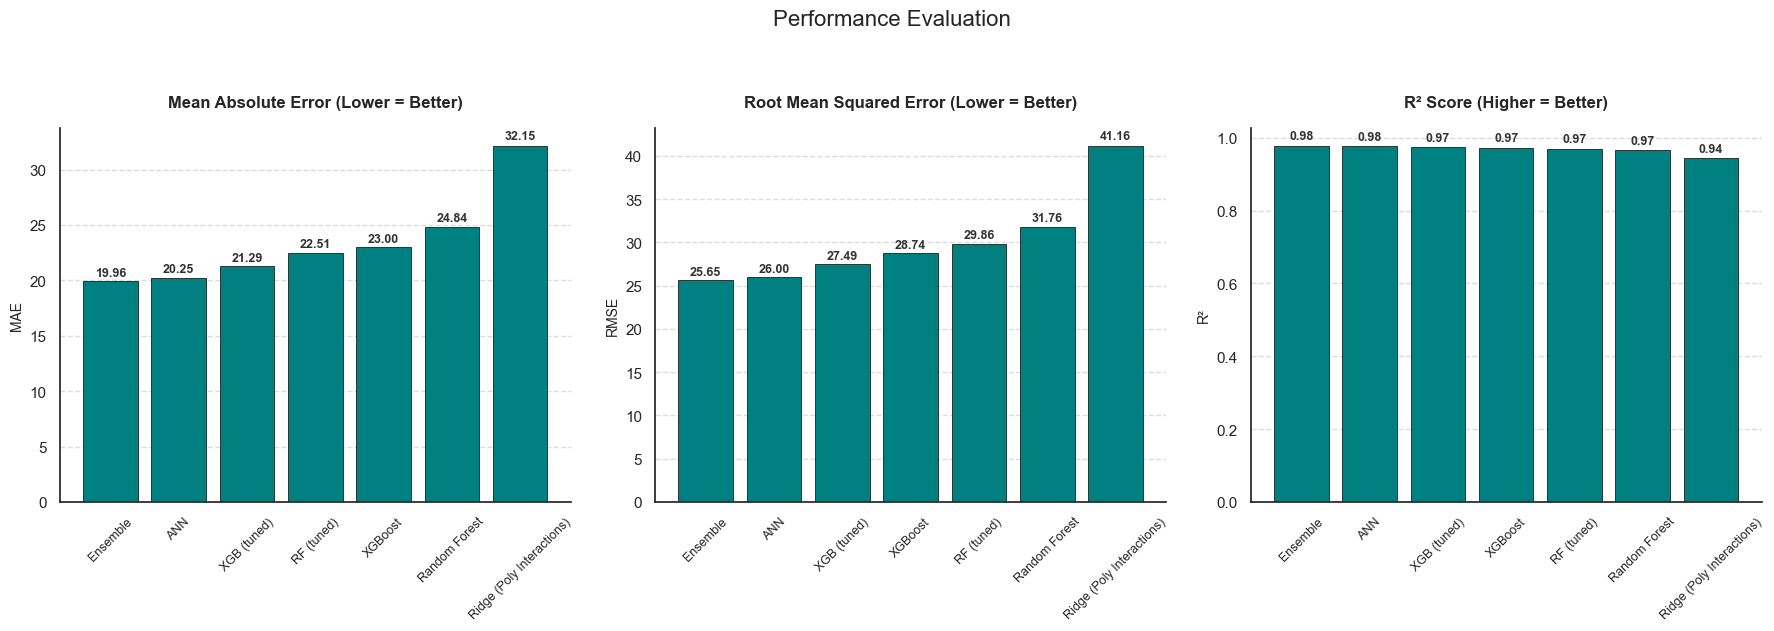

In [187]:
# Performance bar charts
sns.set_theme(style="white", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['MAE', 'RMSE', 'R²']
titles  = ['Mean Absolute Error (Lower = Better)',
           'Root Mean Squared Error (Lower = Better)',
           'R² Score (Higher = Better)']

for i, metric in enumerate(metrics):
    df_sorted = comp.sort_values(by=metric, ascending=(metric != 'R²'))
    ax = axes[i]
    bars = ax.bar(df_sorted['Model'], df_sorted[metric],
                  color='teal', edgecolor='black', linewidth=0.5)
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    sns.despine(ax=ax)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + h*0.01,
                f'{h:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#333333')

plt.suptitle('Performance Evaluation', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('out/performance.png', dpi=300, bbox_inches='tight')
plt.show()


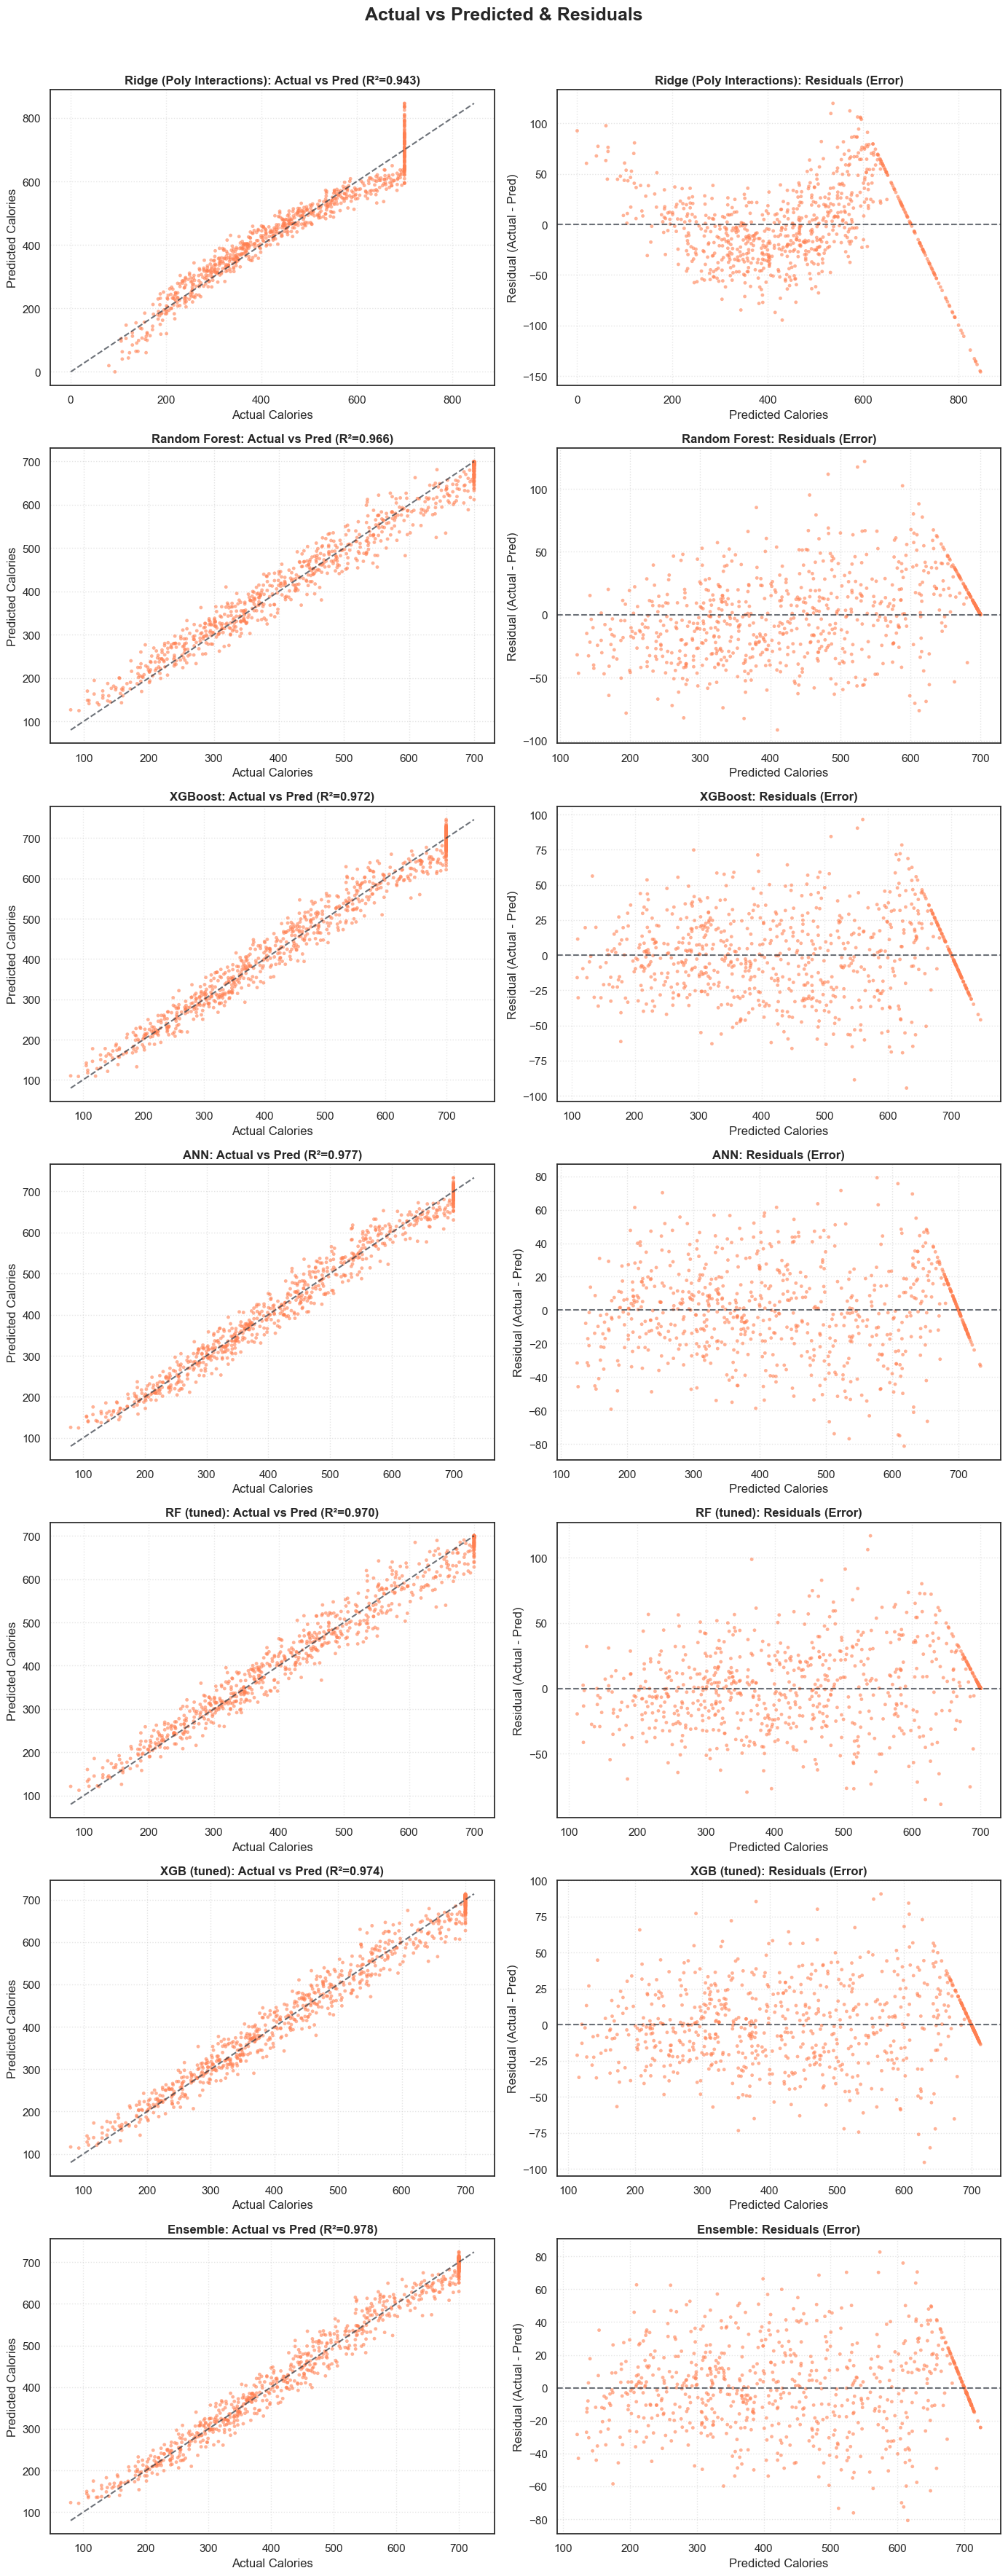

In [191]:

all_models = {
    'Ridge (Poly Interactions)': pred_lr, 
    'Random Forest': pred_rf,
    'XGBoost': pred_xgb, 
    'ANN': pred_ann,
    'RF (tuned)': pred_rf_tuned, 
    'XGB (tuned)': pred_xgb_tuned,
    'Ensemble': pred_ens
}

n_models = len(all_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

for i, (name, pred) in enumerate(all_models.items()):

    actual = y_test_raw.values
    residuals = actual - pred
    ax_avp = axes[i, 0]
    ax_avp.scatter(actual, pred, alpha=0.6, s=12, color='coral', edgecolors='none')
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax_avp.plot(lims, lims, color='#2F3640', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax_avp.set_title(f'{name}: Actual vs Pred (R²={results[name]["R2"]:.3f})', fontweight='bold')
    ax_avp.set_xlabel('Actual Calories')
    ax_avp.set_ylabel('Predicted Calories')
    ax_avp.grid(True, linestyle=':', alpha=0.5)
    ax_res = axes[i, 1]
    ax_res.scatter(pred, residuals, alpha=0.6, s=12, color='coral', edgecolors='none')
    ax_res.axhline(0, color='#2F3640', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax_res.set_title(f'{name}: Residuals (Error)', fontweight='bold')
    ax_res.set_xlabel('Predicted Calories')
    ax_res.set_ylabel('Residual (Actual - Pred)')
    ax_res.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Actual vs Predicted & Residuals', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('out/act_vs_pred_and_residuals.png', dpi=300, bbox_inches="tight")
plt.show()
